<a href="https://colab.research.google.com/github/kaustubh9306-git/seasonal-agriculture-performance-analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis

## VOIS AICTE Batch 1 2026–2027 Major Project

### Objective

This project analyzes agricultural data across different seasons to identify patterns, trends, relationships, and variations in agricultural performance.

The analysis focuses on:

- Seasonal productivity
- Environmental conditions
- Resource utilization
- Water efficiency
- Economic performance
- Disease and pest risk
- Regional and crop-level differences

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_excel('/content/seasonal_agriculture_performance_dataset.xlsx')

In [17]:
df.head(10)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3
5,SF10006,Gujarat,Raichur,Pulses,Zaid,5.46,356.0,33.6,49.0,8.3,...,0.89,0.72,3.93,68593,302333,269570,-32763,1093,3.596,57.1
6,SF10007,Telangana,Warangal,Wheat,Rabi,8.13,432.2,23.5,50.8,9.5,...,0.87,2.53,20.57,22951,513341,472102,-41239,2368,8.687,31.6
7,SF10008,Tamil Nadu,Ludhiana,Pulses,Kharif,5.34,860.2,29.0,64.9,7.9,...,0.70,1.18,6.30,70042,436200,441265,5065,1704,3.697,54.2
8,SF10009,Karnataka,Guntur,Cotton,Zaid,6.98,624.7,33.4,46.8,7.9,...,0.88,1.53,10.68,70771,525129,755834,230705,5079,2.103,54.7
9,SF10010,Tamil Nadu,Raichur,Chilli,Rabi,13.69,415.8,22.3,57.3,8.6,...,0.70,2.29,31.35,94383,1004072,2958907,1954835,5984,5.239,41.7


In [8]:
df.info(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
df.shape

(4000, 28)

In [10]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [19]:
# Create a copy of the original dataset
df_clean = df.copy()

# Fill missing numerical values with their median
df_clean["Rainfall_mm"] = df_clean["Rainfall_mm"].fillna(
    df_clean["Rainfall_mm"].median()
)

df_clean["Soil_Moisture_pct"] = df_clean["Soil_Moisture_pct"].fillna(
    df_clean["Soil_Moisture_pct"].median()
)

df_clean["Yield_Tonnes_Ha"] = df_clean["Yield_Tonnes_Ha"].fillna(
    df_clean["Yield_Tonnes_Ha"].median()
)

print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())

Missing values after cleaning:
0


In [15]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Duplicate rows:", df_clean.duplicated().sum())

Original shape: (4000, 28)
Cleaned shape: (4000, 28)
Duplicate rows: 0


In [16]:
print("SEASONS")
print(df_clean["Season"].value_counts())

print("\nCROPS")
print(df_clean["Crop"].value_counts())

print("\nSTATES")
print(df_clean["State"].nunique())

print("\nDISTRICTS")
print(df_clean["District"].nunique())

SEASONS
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

CROPS
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

STATES
8

DISTRICTS
10


In [20]:
season_summary = df_clean.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

season_summary

,Average_Yield,Total_Production,Average_Profit,Average_Water_Efficiency,Average_Disease_Risk
Season,,,,,
Kharif,5.63,82387.61,178914.65,5.89,54.47
Rabi,5.04,67498.88,87689.47,5.19,40.48
Zaid,4.64,23098.35,-24804.82,4.41,38.22


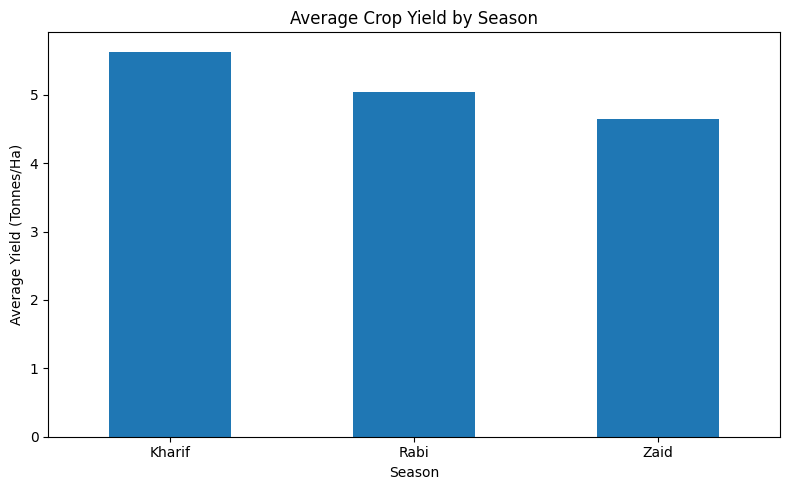

In [21]:
import matplotlib.pyplot as plt

season_summary["Average_Yield"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
economic_summary = df_clean.groupby("Season").agg(
    Average_Market_Price=("Market_Price_INR_Tonne", "mean"),
    Average_Total_Cost=("Total_Cost_INR", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean")
).round(2)

economic_summary

,Average_Market_Price,Average_Total_Cost,Average_Revenue,Average_Profit
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


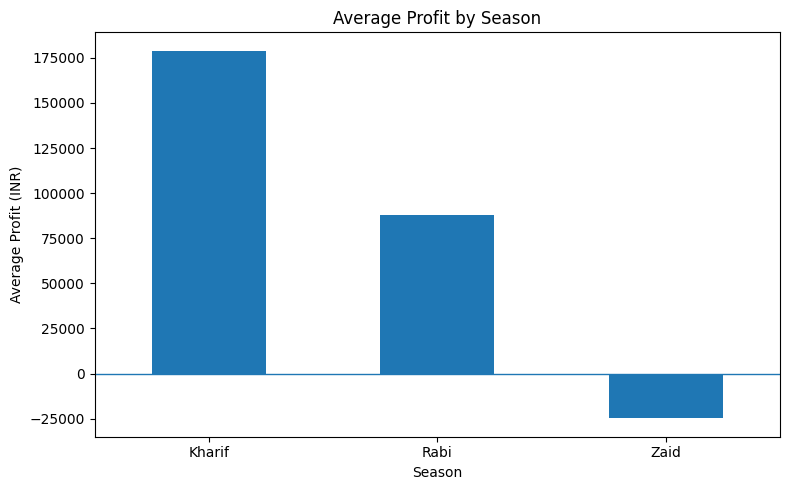

In [23]:
import matplotlib.pyplot as plt

economic_summary["Average_Profit"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [24]:
crop_season_yield = df_clean.pivot_table(
    index="Crop",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean"
).round(2)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


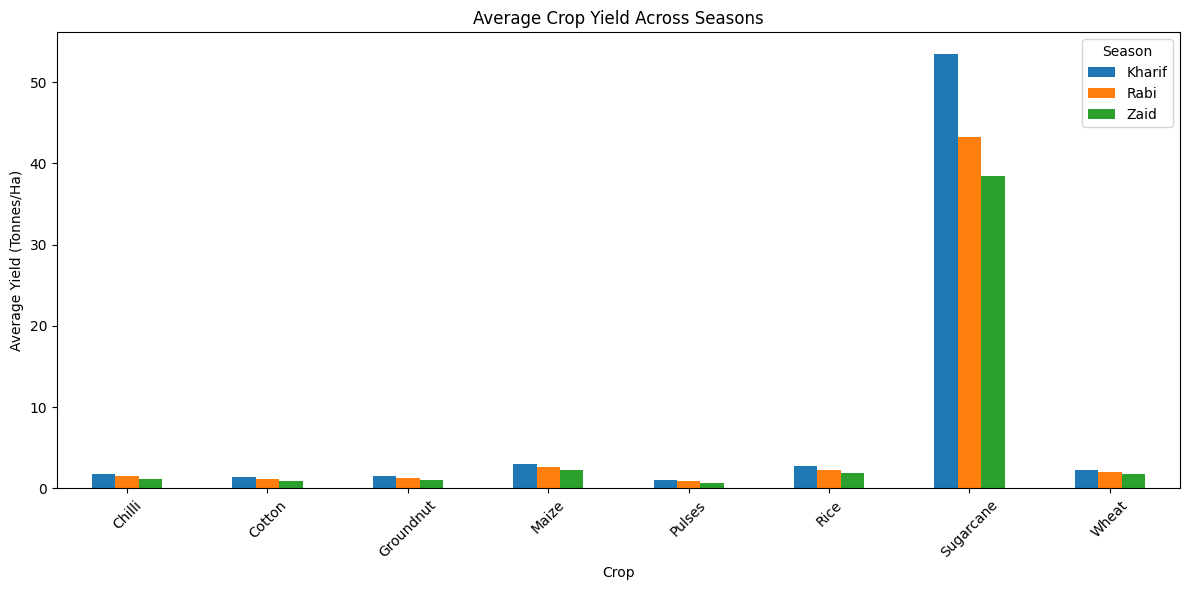

In [25]:
crop_season_yield.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

In [27]:
crop_season_profit= df_clean.pivot_table(

      index="Crop",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"

).round(2)

crop_season_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


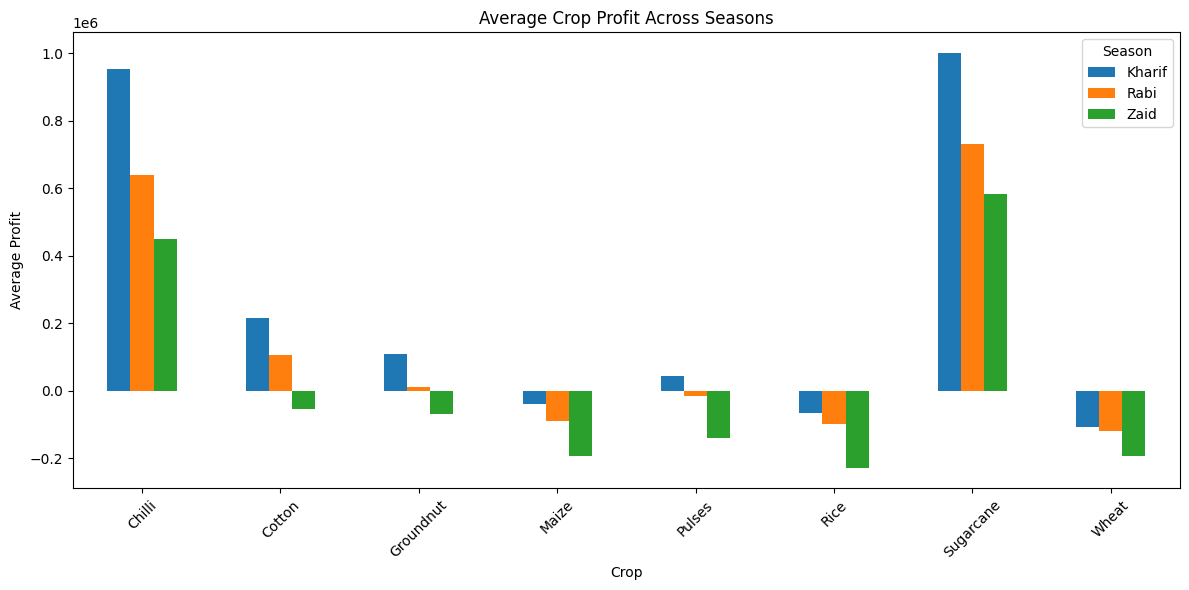

In [28]:
crop_season_profit.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Crop Profit Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Profit")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

In [29]:
environment_summary = df_clean.groupby("Season").agg(
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Temperature=("Avg_Temperature_C", "mean"),
    Average_Humidity=("Humidity_pct", "mean"),
    Average_Sunlight=("Sunlight_Hours_Day", "mean"),
    Average_Soil_Moisture=("Soil_Moisture_pct", "mean"),
    Average_Soil_pH=("Soil_pH", "mean")
).round(2)

environment_summary

,Average_Rainfall,Average_Temperature,Average_Humidity,Average_Sunlight,Average_Soil_Moisture,Average_Soil_pH
Season,,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15,6.73
Rabi,437.62,23.49,57.89,7.59,24.07,6.67
Zaid,304.65,31.04,52.01,8.18,19.28,6.69


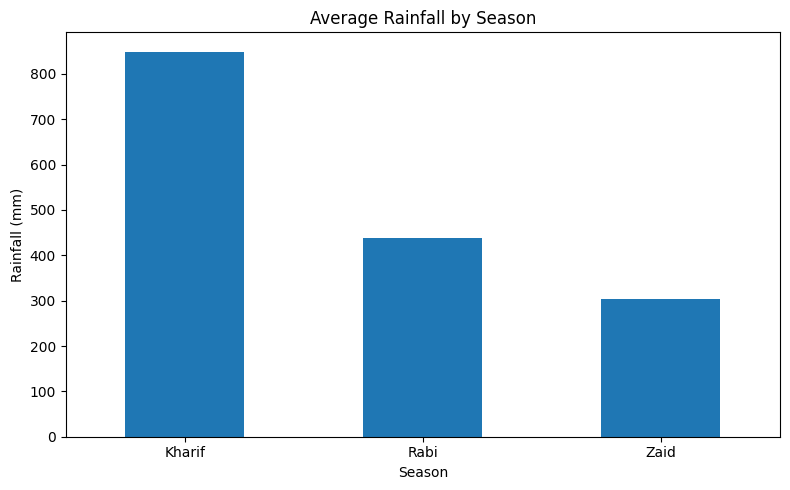

In [30]:
environment_summary["Average_Rainfall"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

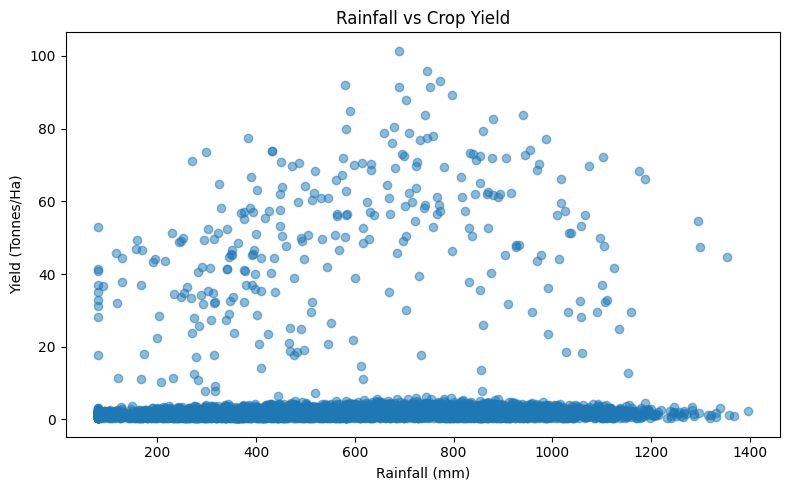

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["Rainfall_mm"],
    df_clean["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [32]:
rainfall_yield_corr = df_clean[
    ["Rainfall_mm", "Yield_Tonnes_Ha"]
].corr()

rainfall_yield_corr

,Rainfall_mm,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.030951
Yield_Tonnes_Ha,0.030951,1.000000


Rainfall and Yield Relationship:
The correlation between rainfall and crop yield was approximately 0.031, indicating a very weak positive linear relationship. This suggests that rainfall alone does not strongly explain yield variation in the dataset. Although Kharif recorded higher average rainfall and yield than other seasons, the weak overall correlation indicates that other factors such as crop type, temperature, soil conditions, irrigation, and resource usage may also contribute to yield differences.

In [33]:
environment_yield_corr = df_clean[
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day",
        "Soil_pH",
        "Soil_Moisture_pct",
        "Yield_Tonnes_Ha"
    ]
].corr()["Yield_Tonnes_Ha"].sort_values(ascending=False)

environment_yield_corr

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Rainfall_mm,0.030951
Humidity_pct,0.012297
Soil_Moisture_pct,0.010999
Avg_Temperature_C,0.009996
Sunlight_Hours_Day,-0.015341
Soil_pH,-0.020672


Environmental Factors and Yield:
Correlation analysis showed very weak linear relationships between the measured environmental variables and crop yield. Rainfall had the highest correlation with yield at only 0.031, while humidity, soil moisture, temperature, sunlight, and soil pH had correlations close to zero. Therefore, no individual environmental variable showed a strong linear association with yield in this dataset. This suggests that agricultural performance may depend on a combination of crop characteristics, farming practices, resource usage, and economic factors rather than a single environmental variable.

In [34]:
resource_yield_corr = df_clean[
    [
        "Nitrogen_kg_ha",
        "Phosphorus_kg_ha",
        "Potassium_kg_ha",
        "Fertilizer_kg_ha",
        "Pesticide_Litre_ha",
        "Water_Used_m3",
        "Water_Efficiency_t_per_1000m3",
        "Yield_Tonnes_Ha"
    ]
].corr()["Yield_Tonnes_Ha"].sort_values(ascending=False)

resource_yield_corr

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Potassium_kg_ha,0.003382
Fertilizer_kg_ha,0.000018
Pesticide_Litre_ha,-0.007779


Resource Usage and Yield:
Water efficiency showed a very strong positive correlation with yield (r = 0.913). However, water efficiency is a derived performance metric that incorporates crop yield, so this strong correlation should not be interpreted as a causal relationship. Water used showed a moderate positive correlation with yield (r = 0.386), while nitrogen, phosphorus, potassium, fertilizer, and pesticide usage showed very weak linear relationships with yield. This indicates that resource quantities alone do not show strong individual linear associations with yield in the dataset.

In [35]:
resource_season_summary = df_clean.groupby("Season").agg(
    Average_Nitrogen=("Nitrogen_kg_ha", "mean"),
    Average_Phosphorus=("Phosphorus_kg_ha", "mean"),
    Average_Potassium=("Potassium_kg_ha", "mean"),
    Average_Fertilizer=("Fertilizer_kg_ha", "mean"),
    Average_Pesticide=("Pesticide_Litre_ha", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

resource_season_summary

,Average_Nitrogen,Average_Phosphorus,Average_Potassium,Average_Fertilizer,Average_Pesticide,Average_Water_Used,Average_Water_Efficiency
Season,,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20,5.89
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99,5.19
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89,4.41


Seasonal Resource Usage:
Resource inputs such as nitrogen, phosphorus, potassium, fertilizer, and pesticide usage remained relatively consistent across seasons. Water usage showed greater variation, with Zaid recording the highest average water consumption (6,419.89 m³) and Rabi the lowest (5,846.99 m³). Despite its higher water usage, Zaid had the lowest average water efficiency (4.41 t/1000m³), while Kharif achieved the highest (5.89 t/1000m³). This indicates substantial seasonal variation in water-use performance.

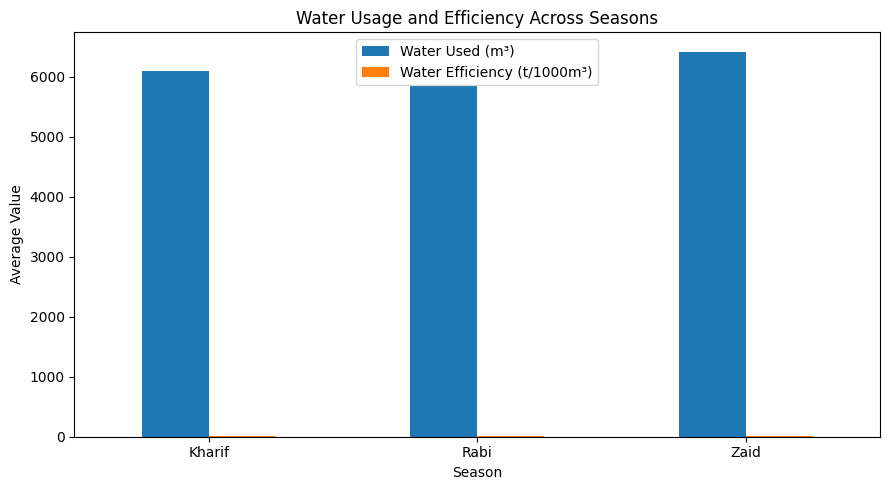

In [36]:
resource_season_summary[
    ["Average_Water_Used", "Average_Water_Efficiency"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Water Usage and Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(
    ["Water Used (m³)", "Water Efficiency (t/1000m³)"]
)
plt.tight_layout()
plt.show()

In [37]:
from scipy.stats import f_oneway

kharif_yield = df_clean[df_clean["Season"] == "Kharif"]["Yield_Tonnes_Ha"]
rabi_yield = df_clean[df_clean["Season"] == "Rabi"]["Yield_Tonnes_Ha"]
zaid_yield = df_clean[df_clean["Season"] == "Zaid"]["Yield_Tonnes_Ha"]

f_stat, p_value = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("F-statistic:", round(f_stat, 4))
print("P-value:", p_value)

F-statistic: 1.5439
P-value: 0.21367813841792296


Result: A one-way ANOVA was conducted to compare crop yield across Kharif, Rabi, and Zaid seasons. The analysis produced an F-statistic of 1.5439 and a p-value of 0.2137. Since the p-value is greater than 0.05, the difference in mean yield across seasons was not statistically significant at the 5% significance level. Although Kharif had the highest observed average yield and Zaid the lowest, the available data does not provide sufficient statistical evidence to conclude that season alone significantly affects average yield.

In [38]:
from scipy.stats import f_oneway

kharif_profit = df_clean[df_clean["Season"] == "Kharif"]["Profit_INR"]
rabi_profit = df_clean[df_clean["Season"] == "Rabi"]["Profit_INR"]
zaid_profit = df_clean[df_clean["Season"] == "Zaid"]["Profit_INR"]

f_stat_profit, p_value_profit = f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("F-statistic:", round(f_stat_profit, 4))
print("P-value:", p_value_profit)

F-statistic: 34.2918
P-value: 1.7124156677360182e-15


Result: A one-way ANOVA was performed to determine whether average profit differed across Kharif, Rabi, and Zaid seasons. The test produced an F-statistic of 34.2918 and a p-value of approximately 1.71 × 10⁻¹⁵. Since the p-value is substantially below 0.05, the null hypothesis was rejected. This indicates a statistically significant difference in average agricultural profit across seasons. The result suggests that seasonal variation has a stronger observed association with economic performance than with average yield in this dataset.

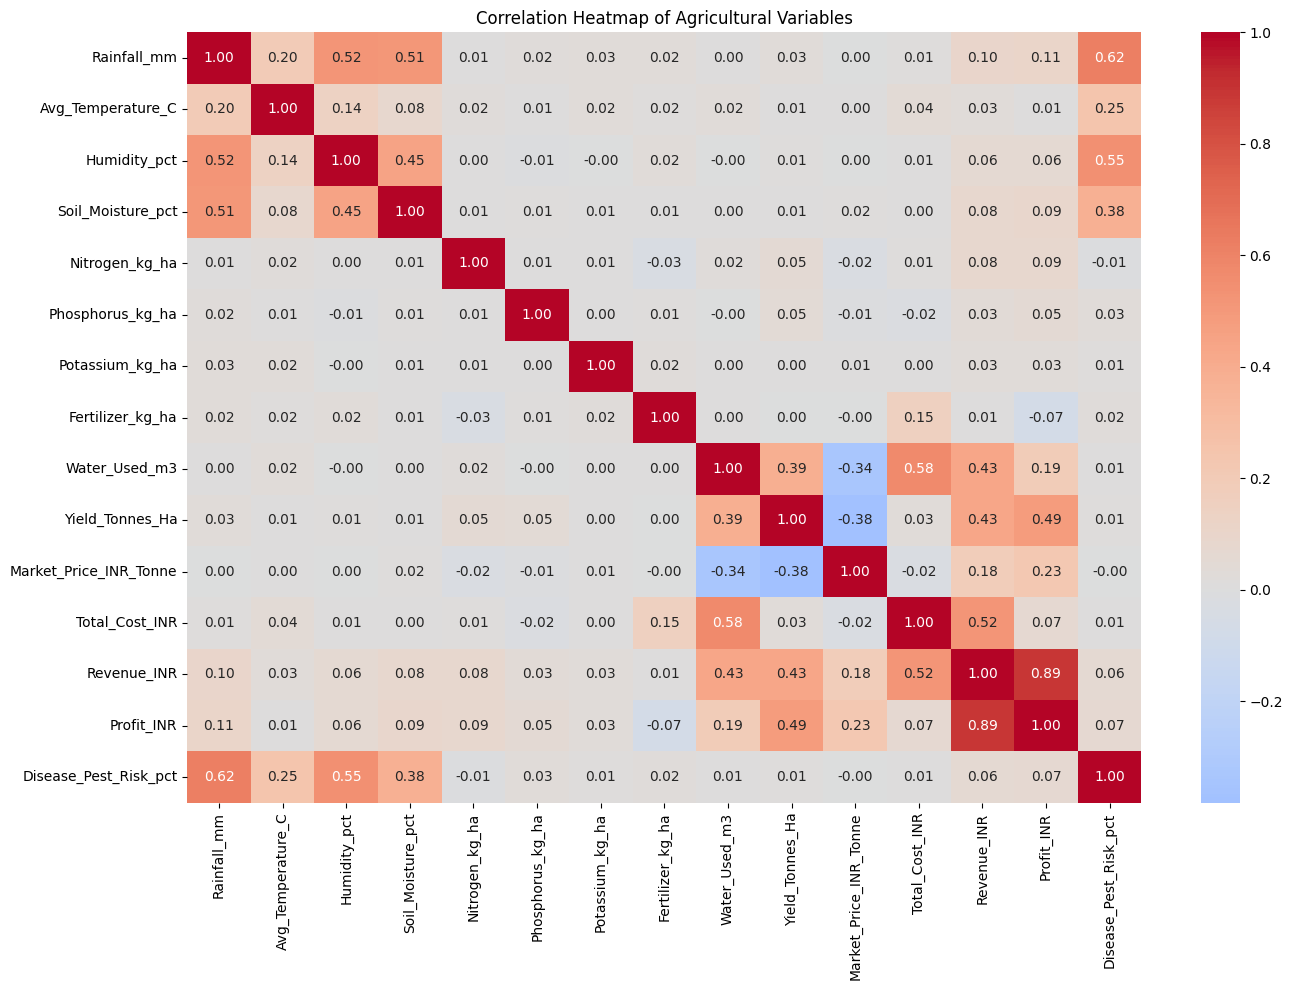

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Water_Used_m3",
    "Yield_Tonnes_Ha",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Disease_Pest_Risk_pct"
]

correlation_matrix = df_clean[correlation_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Agricultural Variables")
plt.tight_layout()
plt.show()

Correlation Analysis: The correlation heatmap was used to examine linear relationships among environmental, resource, productivity, and economic variables. The analysis showed that most individual environmental variables had weak linear relationships with crop yield. Water used showed a moderate positive association with yield, while water efficiency showed a strong association with yield; however, water efficiency is a derived metric involving yield, so this relationship should not be interpreted as causal. Economic variables such as revenue, cost, market price, and profit showed stronger relationships with one another, reflecting their direct connection in agricultural economics.

In [40]:
disease_season = df_clean.groupby("Season").agg(
    Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

disease_season

,Average_Disease_Risk
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


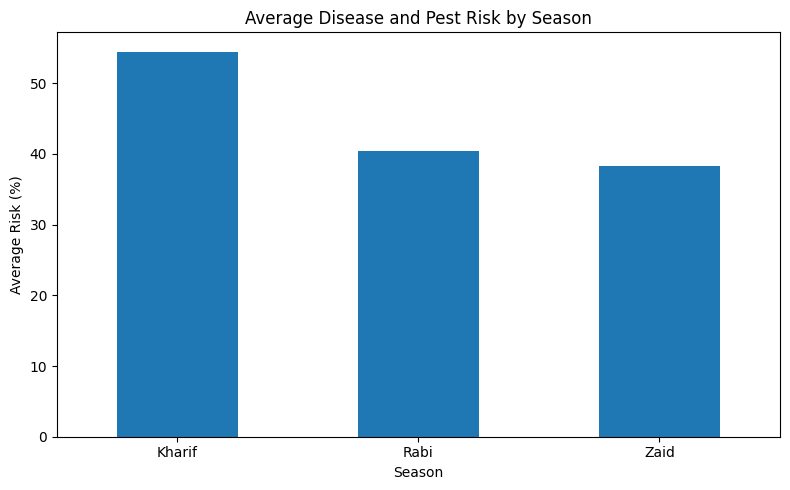

In [41]:
disease_season["Average_Disease_Risk"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Average Risk (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
disease_yield_corr = df_clean[
    ["Disease_Pest_Risk_pct", "Yield_Tonnes_Ha"]
].corr()

disease_yield_corr

,Disease_Pest_Risk_pct,Yield_Tonnes_Ha
Disease_Pest_Risk_pct,1.000000,0.014292
Yield_Tonnes_Ha,0.014292,1.000000


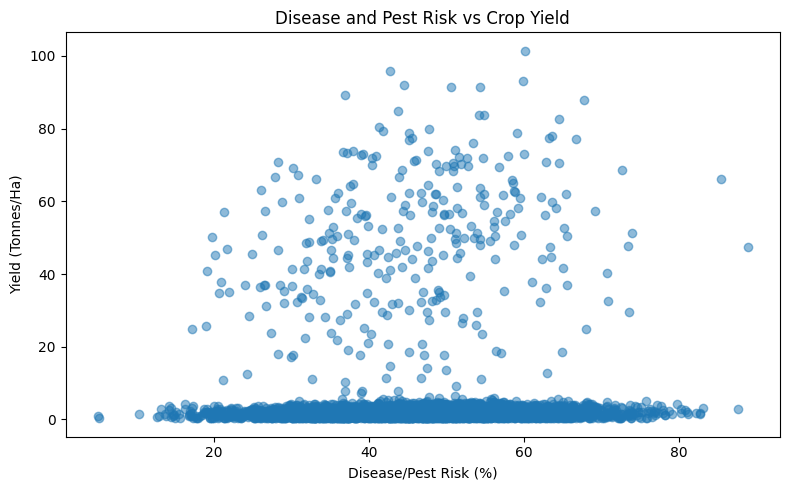

In [43]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["Disease_Pest_Risk_pct"],
    df_clean["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Disease and Pest Risk vs Crop Yield")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

Disease/Pest Risk and Yield: The correlation between disease/pest risk and crop yield was 0.0143, indicating an extremely weak positive linear association. Therefore, disease and pest risk did not show a meaningful linear relationship with yield in this dataset. However, this does not establish that disease and pest factors have no effect on agricultural productivity, as their effects may depend on crop type, environmental conditions, management practices, or nonlinear interactions.

In [44]:
state_season_yield = df_clean.pivot_table(
    index="State",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean"
).round(2)

state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.44,4.07
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.48
Maharashtra,5.43,5.50,2.28
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


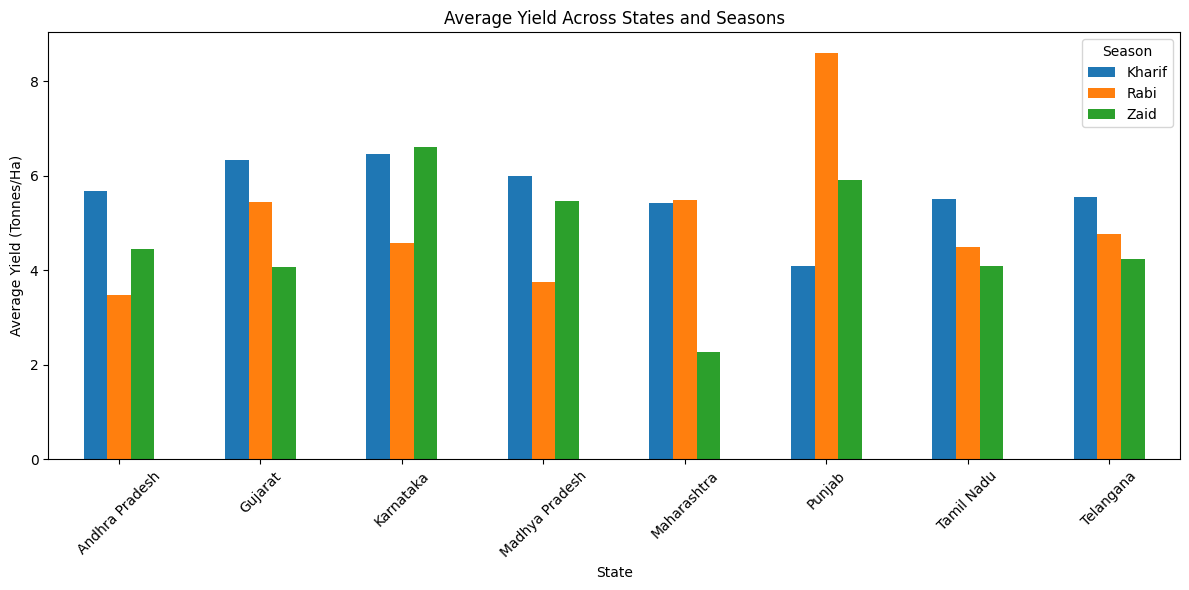

In [45]:
state_season_yield.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Yield Across States and Seasons")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.legend(title="Season")
plt.tight_layout()
plt.show()

### State-wise Seasonal Yield Analysis

The state-wise seasonal analysis shows considerable variation in average crop yield across different regions and seasons. Punjab recorded the highest observed yield during the Rabi season at **8.61 tonnes/ha**, while Karnataka recorded the highest Zaid yield at **6.62 tonnes/ha**. Karnataka also recorded a high Kharif yield of **6.46 tonnes/ha**, making it one of the stronger-performing states across multiple seasons.

Most states recorded their highest average yield during Kharif. However, notable exceptions were observed. Punjab performed substantially better during Rabi, while Karnataka recorded a slightly higher yield during Zaid than Kharif. Maharashtra showed relatively strong Rabi performance at **5.50 tonnes/ha** but much lower Zaid performance at **2.28 tonnes/ha**.

These results indicate that agricultural performance varies across both geography and season. However, the observed differences should not be interpreted as causal effects of season or location alone, because crop composition, farming practices, environmental conditions, and resource usage may also contribute to the observed variation.


In [46]:
state_season_profit = df_clean.pivot_table(
    index="State",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).round(2)

state_season_profit


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


### State-wise Seasonal Profit Analysis

The state-wise seasonal profit analysis shows substantial variation in economic performance across regions and seasons. Gujarat recorded the highest average Kharif profit at approximately **₹2.17 lakh**, followed by Tamil Nadu and Karnataka. During Rabi, **Punjab recorded the highest average profit of ₹1.69 lakh**, followed by Maharashtra at approximately ₹1.60 lakh.

Zaid showed the weakest economic performance across most states. Average Zaid profit was negative in five of the eight states, with Gujarat recording the largest average loss of approximately **₹1.07 lakh**. Andhra Pradesh also recorded a substantial average Zaid loss of approximately ₹84,085.

Punjab and Karnataka were notable exceptions, recording positive average Zaid profits of **₹62,110** and **₹23,311**, respectively. Madhya Pradesh was approximately at break-even during Zaid, with an average profit of only **₹210**.

Overall, the analysis demonstrates that agricultural profitability varies considerably across both region and season. Therefore, seasonal agricultural planning should consider regional differences rather than assuming that a particular season will produce the same economic outcome across all locations. These results are observational and may also reflect differences in crop composition, resource usage, environmental conditions, and market conditions across states.


In [47]:
Q1 = df_clean["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df_clean["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_outliers = df_clean[
    (df_clean["Yield_Tonnes_Ha"] < lower_bound) |
    (df_clean["Yield_Tonnes_Ha"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Yield Outliers:", len(yield_outliers))

Q1: 1.05
Q3: 2.83
IQR: 1.78
Lower Bound: -1.6199999999999999
Upper Bound: 5.5
Number of Yield Outliers: 302


In [48]:
yield_outlier_crop = yield_outliers["Crop"].value_counts()

print(yield_outlier_crop)

Crop
Sugarcane    293
Maize          7
Rice           2
Name: count, dtype: int64


### Yield Outlier Analysis

The IQR method identified **302 observations** as statistical outliers in crop yield, using an upper threshold of **5.50 tonnes/ha**. Further investigation showed that **293 of these 302 observations (approximately 97%) belonged to Sugarcane**, while only 7 belonged to Maize and 2 to Rice.

This indicates that the identified outliers are largely associated with the naturally higher yield scale of Sugarcane rather than obvious data-quality errors. Therefore, these observations were retained in the dataset instead of being removed. This finding also demonstrates the importance of considering crop type when interpreting statistical outliers in agricultural datasets.


In [49]:
Q1_profit = df_clean["Profit_INR"].quantile(0.25)
Q3_profit = df_clean["Profit_INR"].quantile(0.75)

IQR_profit = Q3_profit - Q1_profit

lower_profit = Q1_profit - 1.5 * IQR_profit
upper_profit = Q3_profit + 1.5 * IQR_profit

profit_outliers = df_clean[
    (df_clean["Profit_INR"] < lower_profit) |
    (df_clean["Profit_INR"] > upper_profit)
]

print("Q1:", Q1_profit)
print("Q3:", Q3_profit)
print("IQR:", IQR_profit)
print("Lower Bound:", lower_profit)
print("Upper Bound:", upper_profit)
print("Number of Profit Outliers:", len(profit_outliers))

Q1: -148731.75
Q3: 216187.75
IQR: 364919.5
Lower Bound: -696111.0
Upper Bound: 763567.0
Number of Profit Outliers: 404


In [50]:
profit_outlier_crop = profit_outliers["Crop"].value_counts()

print(profit_outlier_crop)

Crop
Chilli       161
Sugarcane    146
Cotton        33
Maize         17
Rice          14
Pulses        12
Wheat         11
Groundnut     10
Name: count, dtype: int64


Profit Outlier Analysis:
The IQR method identified 404 observations as profit outliers. Chilli accounted for 161 observations and Sugarcane accounted for 146, together representing approximately 76% of the identified outliers. The remaining outliers were distributed across Cotton, Maize, Rice, Pulses, Wheat, and Groundnut. The concentration of outliers in particular crops indicates that differences in crop profitability and economic scale may contribute to the extreme values. Therefore, the identified observations were retained rather than removed, as they may represent legitimate variations in agricultural profitability.

In [51]:
print("KEY FINDINGS")

print("1. Kharif had the highest average yield:",
      round(season_summary.loc["Kharif", "Average_Yield"], 2), "tonnes/ha.")

print("2. Zaid had the lowest average profit:",
      round(season_summary.loc["Zaid", "Average_Profit"], 2), "INR.")

print("3. Kharif had the highest average profit:",
      round(season_summary.loc["Kharif", "Average_Profit"], 2), "INR.")

print("4. Kharif had the highest disease/pest risk:",
      round(season_summary.loc["Kharif", "Average_Disease_Risk"], 2), "%.")

print("5. Zaid had the highest average water usage:",
      round(resource_season_summary.loc["Zaid", "Average_Water_Used"], 2), "m3.")

print("6. Rainfall-yield correlation:",
      round(rainfall_yield_corr.loc["Rainfall_mm", "Yield_Tonnes_Ha"], 4))

print("7. Seasonal yield ANOVA p-value:",
      round(p_value, 4))

print("8. Seasonal profit ANOVA p-value:",
      f"{p_value_profit:.2e}")

KEY FINDINGS
1. Kharif had the highest average yield: 5.63 tonnes/ha.
2. Zaid had the lowest average profit: -24804.82 INR.
3. Kharif had the highest average profit: 178914.65 INR.
4. Kharif had the highest disease/pest risk: 54.47 %.
5. Zaid had the highest average water usage: 6419.89 m3.
6. Rainfall-yield correlation: 0.031
7. Seasonal yield ANOVA p-value: 0.2137
8. Seasonal profit ANOVA p-value: 1.71e-15


### Key Findings

1. **Seasonal yield:** Kharif recorded the highest average crop yield at **5.63 tonnes/ha**, followed by Rabi at 5.04 tonnes/ha and Zaid at 4.64 tonnes/ha.

2. **Seasonal profitability:** Kharif recorded the highest average profit of **₹178,914.65**, while Zaid recorded the lowest average profit of **-₹24,804.82**, indicating an average loss during the Zaid season.

3. **Disease and pest risk:** Kharif had the highest average disease and pest risk at **54.47%**, compared with 40.48% in Rabi and 38.22% in Zaid.

4. **Water usage:** Zaid had the highest average water usage at **6,419.89 m³**, while also having the lowest average water efficiency at 4.41 tonnes/1,000 m³.

5. **Environmental relationship:** Rainfall showed an extremely weak positive linear correlation with crop yield (**r = 0.031**). This indicates that rainfall alone did not explain much of the variation in yield in this dataset.

6. **Seasonal yield significance:** The one-way ANOVA for yield produced a **p-value of 0.2137**. Since this is greater than 0.05, the observed differences in average yield across seasons were not statistically significant at the 5% significance level.

7. **Seasonal profit significance:** The one-way ANOVA for profit produced a **p-value of 1.71 × 10⁻¹⁵**, which is far below 0.05. This provides strong statistical evidence that average profit differs across seasons.

8. **Crop-level profitability:** Crop-wise analysis showed that profitability varied substantially by crop and season. Chilli and Sugarcane remained profitable across all three seasons, while several crops showed losses, particularly during Zaid.

9. **Regional variation:** State-wise analysis showed considerable differences in seasonal performance. Punjab recorded the highest observed Rabi yield at **8.61 tonnes/ha**, while Karnataka recorded the highest observed Zaid yield at **6.62 tonnes/ha**.

10. **Outlier analysis:** Yield outlier analysis identified 302 observations, of which **293 were Sugarcane**. Profit outlier analysis identified 404 observations, with Chilli and Sugarcane together accounting for approximately **76%** of them. These observations were retained because they can represent legitimate differences in crop productivity and profitability rather than data errors.


### Recommendations

Based on the analysis, the following recommendations can be made:

1. **Consider season-specific crop planning:** Since profitability varied considerably across seasons, crop selection should consider both the crop and the season rather than relying on season alone.

2. **Investigate Zaid-season profitability:** Zaid recorded the lowest average profit (**-₹24,804.82**) and the lowest average water efficiency (**4.41 tonnes/1,000 m³**). Farmers and planners should investigate the cost, revenue, irrigation requirements, and crop combinations associated with Zaid cultivation.

3. **Improve water management during Zaid:** Zaid recorded the highest average water usage (**6,419.89 m³**) despite having the lowest water efficiency. More efficient irrigation and water-management practices could therefore be investigated for this season.

4. **Strengthen disease and pest monitoring during Kharif:** Kharif recorded the highest average disease and pest risk (**54.47%**). Increased monitoring and timely preventive measures may help manage this higher observed risk.

5. **Use crop-level profitability for planning:** Chilli and Sugarcane remained profitable across all three seasons, while several other crops showed losses in certain seasons. Therefore, crop-specific profitability should be considered when evaluating seasonal agricultural plans.

6. **Consider regional differences:** Agricultural performance varied considerably across states. Seasonal planning should therefore account for regional conditions instead of assuming that the same crop-season combination will perform similarly everywhere.

7. **Avoid relying on rainfall alone to predict yield:** Rainfall had an extremely weak correlation with yield (**r = 0.031**). Yield planning should therefore consider multiple factors, including crop type, farming practices, resources, environmental conditions, and economic factors.

8. **Investigate the causes of seasonal profit differences:** The profit ANOVA showed a statistically significant difference across seasons (**p < 0.05**). Further analysis of crop mix, market prices, production costs, farm practices, and resource usage could help explain these differences.


## Conclusion

This project analyzed seasonal variations in agricultural performance using data related to crop yield, production, environmental conditions, resource usage, economic outcomes, disease and pest risk, and regional differences.

The analysis showed that Kharif recorded the highest average yield of 5.63 tonnes/ha and the highest average profit of ₹178,914.65, while Zaid recorded the lowest average profit of -₹24,804.82. Zaid also had the highest average water usage and the lowest water efficiency, indicating that its resource and economic performance requires further investigation.

Crop-level analysis showed that seasonal performance varies considerably between crops. Chilli and Sugarcane remained profitable across all three seasons, while several other crops showed losses, particularly during Zaid. Regional analysis also revealed differences in seasonal performance across states, demonstrating that agricultural planning should consider both crop and geographical conditions.

Correlation analysis showed that individual environmental variables had very weak linear relationships with yield. The seasonal yield ANOVA also did not show a statistically significant difference at the 5% significance level. In contrast, the seasonal profit ANOVA showed a statistically significant difference in average profit across seasons.

Overall, the findings demonstrate that agricultural performance is influenced by multiple interacting factors rather than season alone. The results can support more informed seasonal crop planning, resource management, risk monitoring, and further investigation into the factors responsible for differences in agricultural profitability.
